# Data Loading

In [1]:
# Import Library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.simplefilter("ignore")

RANDOM_STATE_SEED = 12

In [2]:
import kagglehub
path = kagglehub.dataset_download("solarmainframe/ids-intrusion-csv")

Using Colab cache for faster access to the 'ids-intrusion-csv' dataset.


In [3]:
df_dataset = pd.read_csv(path + "/02-14-2018.csv")
df_dataset

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,14/02/2018 08:31:01,112641719,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320859.5,139.300036,56320958,56320761,Benign
1,0,0,14/02/2018 08:33:50,112641466,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320733.0,114.551299,56320814,56320652,Benign
2,0,0,14/02/2018 08:36:39,112638623,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56319311.5,301.934596,56319525,56319098,Benign
3,22,6,14/02/2018 08:40:13,6453966,15,10,1239,2273,744,0,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
4,22,6,14/02/2018 08:40:23,8804066,14,11,1143,2209,744,0,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,80,6,14/02/2018 10:53:23,10156986,5,5,1089,1923,587,0,...,20,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
1048571,80,6,14/02/2018 10:53:33,117,2,0,0,0,0,0,...,20,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
1048572,80,6,14/02/2018 10:53:28,5095331,3,1,0,0,0,0,...,20,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
1048573,80,6,14/02/2018 10:53:28,5235511,3,1,0,0,0,0,...,20,0.0,0.0,0,0,0.0,0.000000,0,0,Benign


In [4]:
df_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 80 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Dst Port           1048575 non-null  int64  
 1   Protocol           1048575 non-null  int64  
 2   Timestamp          1048575 non-null  object 
 3   Flow Duration      1048575 non-null  int64  
 4   Tot Fwd Pkts       1048575 non-null  int64  
 5   Tot Bwd Pkts       1048575 non-null  int64  
 6   TotLen Fwd Pkts    1048575 non-null  int64  
 7   TotLen Bwd Pkts    1048575 non-null  int64  
 8   Fwd Pkt Len Max    1048575 non-null  int64  
 9   Fwd Pkt Len Min    1048575 non-null  int64  
 10  Fwd Pkt Len Mean   1048575 non-null  float64
 11  Fwd Pkt Len Std    1048575 non-null  float64
 12  Bwd Pkt Len Max    1048575 non-null  int64  
 13  Bwd Pkt Len Min    1048575 non-null  int64  
 14  Bwd Pkt Len Mean   1048575 non-null  float64
 15  Bwd Pkt Len Std    1048575 non-n

# Data Cleaning

### Handling Missing values columns

In [5]:
class MissingValueColumnDropper(BaseEstimator, TransformerMixin):
    """Custom Transformer to drop columns that contain any missing values."""
    def __init__(self):
        self.cols_to_drop = []

    def fit(self, X, y=None):
        missing_cols = X.columns[X.isnull().any()].tolist()
        self.cols_to_drop = missing_cols
        if self.cols_to_drop:
            print(f"During fit (MissingValueColumnDropper), identified columns with missing values: {self.cols_to_drop}")
        else:
            print("During fit (MissingValueColumnDropper), no columns with missing values were found.")
        return self

    def transform(self, X):
        if self.cols_to_drop:
            existing_cols_to_drop = [col for col in self.cols_to_drop if col in X.columns]
            if existing_cols_to_drop:
                print(f"Dropping columns (MissingValueColumnDropper): {existing_cols_to_drop}")
                return X.drop(columns=existing_cols_to_drop)
            else:
                return X.copy()
        else:
            return X.copy()

### Drop columns that having Infinite Values

In [6]:
class InfiniteValueColumnDropper(BaseEstimator, TransformerMixin):
    """Custom Transformer to drop columns that contain any infinite values."""
    def __init__(self):
        self.cols_to_drop = []

    def fit(self, X, y=None):
        # Ensure we only check numeric columns for infinite values
        numeric_cols = X.select_dtypes(include=np.number).columns
        if not numeric_cols.empty:
            infinite_cols = numeric_cols[(X[numeric_cols] == np.inf).any() | (X[numeric_cols] == -np.inf).any()].tolist()
            self.cols_to_drop = infinite_cols
        else:
            self.cols_to_drop = []

        if self.cols_to_drop:
            print(f"During fit (InfiniteValueColumnDropper), identified columns with infinite values: {self.cols_to_drop}")
        else:
            print("During fit (InfiniteValueColumnDropper), no columns with infinite values were found.")
        return self

    def transform(self, X):
        if self.cols_to_drop:
            existing_cols_to_drop = [col for col in self.cols_to_drop if col in X.columns]
            if existing_cols_to_drop:
                print(f"Dropping columns (InfiniteValueColumnDropper): {existing_cols_to_drop}")
                return X.drop(columns=existing_cols_to_drop)
            else:
                return X.copy()
        else:
            return X.copy()

### Removes Zero-Variance(Constant) Columns

In [7]:
class ZeroVarianceColumnDropper(BaseEstimator, TransformerMixin):
    """Custom Transformer to drop columns that have zero variance."""
    def __init__(self):
        self.constant_cols = []

    def fit(self, X, y=None):
        numerical_cols = X.select_dtypes(include=np.number).columns
        if not numerical_cols.empty:
            variances = X[numerical_cols].var()
            self.constant_cols = variances[variances == 0].index.tolist()
        else:
            self.constant_cols = []

        if self.constant_cols:
            print(f"During fit (ZeroVarianceColumnDropper), identified zero-variance columns: {self.constant_cols}")
        else:
            print("During fit (ZeroVarianceColumnDropper), no zero-variance columns were found.")
        return self

    def transform(self, X):
        if self.constant_cols:
            existing_cols_to_drop = [col for col in self.constant_cols if col in X.columns]
            if existing_cols_to_drop:
                print(f"Dropping columns (ZeroVarianceColumnDropper): {existing_cols_to_drop}")
                return X.drop(columns=existing_cols_to_drop)
            else:
                return X.copy()
        else:
            return X.copy()

### Removes Duplicate Columns
It take too much time for execution 1 hour

In [8]:
class DuplicateColumnDropper(BaseEstimator, TransformerMixin):
    """Custom Transformer to drop columns that are duplicates of others based on content."""
    def __init__(self):
        # No need to store cols_to_drop explicitly if using T.drop_duplicates().T
        pass

    def fit(self, X, y=None):
        # The logic for dropping duplicates is applied directly in transform
        return self

    def transform(self, X):
        print("Dropping duplicate columns using X.T.drop_duplicates().T")
        original_cols = X.columns
        # Drop duplicate columns by transposing, dropping duplicates, and transposing back
        df_unique_cols = X.T.drop_duplicates().T
        dropped_cols = list(set(original_cols) - set(df_unique_cols.columns))
        if dropped_cols:
            print(f"Dropped duplicate columns: {dropped_cols}")
        else:
            print("No duplicate columns found and dropped.")
        return df_unique_cols

In [9]:
class ManualDuplicateColumnDropper(BaseEstimator, TransformerMixin):
    """Custom Transformer to drop a specified list of columns."""
    def __init__(self, columns_to_drop=None):
        self.columns_to_drop = columns_to_drop if columns_to_drop is not None else []

    def fit(self, X, y=None):
        # Nothing to fit, columns are specified at initialization
        print(f"During fit (ManualColumnDropper), identified specific columns to drop: {self.columns_to_drop}")
        return self

    def transform(self, X):
        if self.columns_to_drop:
            existing_cols_to_drop = [col for col in self.columns_to_drop if col in X.columns]
            if existing_cols_to_drop:
                print(f"Dropping specific manual columns (ManualColumnDropper): {existing_cols_to_drop}")
                return X.drop(columns=existing_cols_to_drop)
            else:
                print("No specified columns found in the DataFrame to drop. Returning original DataFrame.")
                return X.copy()
        else:
            print("No columns specified for dropping. Returning original DataFrame.")
            return X.copy()

### Drop Timestamp Column

In [10]:
class TimestampColumnDropper(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if 'Timestamp' in X.columns:
            print("Dropping 'Timestamp' column.")
            return X.drop(columns=['Timestamp'])
        return X

In [11]:
# --- Full Data Cleaning Pipeline ---

columns_to_drop_manual = ['SYN Flag Cnt', 'Fwd Seg Size Avg', 'Subflow Fwd Pkts',
                       'Subflow Fwd Byts', 'Subflow Bwd Pkts', 'Subflow Bwd Byts']

# Reload the raw dataset to apply the cleaning pipeline from scratch for demonstration
print(f"Original raw dataset shape: {df_dataset.shape}")

# Create the comprehensive data cleaning pipeline
full_data_cleaning_pipeline = Pipeline([
    ('missing_value_dropper', MissingValueColumnDropper()),
    ('infinite_value_dropper', InfiniteValueColumnDropper()),
    ('zero_variance_dropper', ZeroVarianceColumnDropper()),
    ('drop_manual_specific_cols', ManualDuplicateColumnDropper(columns_to_drop_manual)),
    ('timestamp_dropper', TimestampColumnDropper()),
    #('duplicate_column_dropper', DuplicateColumnDropper())
])

# Apply the pipeline
df_dataset = full_data_cleaning_pipeline.fit_transform(df_dataset)

print(f"\nCleaned dataset shape after full pipeline: {df_dataset.shape}")

Original raw dataset shape: (1048575, 80)
During fit (MissingValueColumnDropper), identified columns with missing values: ['Flow Byts/s']
Dropping columns (MissingValueColumnDropper): ['Flow Byts/s']
During fit (InfiniteValueColumnDropper), identified columns with infinite values: ['Flow Pkts/s']
Dropping columns (InfiniteValueColumnDropper): ['Flow Pkts/s']
During fit (ZeroVarianceColumnDropper), identified zero-variance columns: ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg']
Dropping columns (ZeroVarianceColumnDropper): ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg']
During fit (ManualColumnDropper), identified specific columns to drop: ['SYN Flag Cnt', 'Fwd Seg Size Avg', 'Subflow Fwd Pkts', 'Subflow Fwd Byts', 'Subflo

# Feature Engineering

### Label Encode Target Column

In [12]:
from sklearn.preprocessing import LabelEncoder

# Step 1: Label encode on target column binary classification
df_dataset['Label'] = df_dataset['Label'].replace(['FTP-BruteForce', 'SSH-Bruteforce'], 'BruteForce')
le = LabelEncoder()
df_dataset['Label'] = le.fit_transform(df_dataset['Label'])
print(f"Unique labels after encoding: {df_dataset['Label'].unique()}")
print(f"Original labels mapping: {le.inverse_transform(np.unique(df_dataset['Label']))}")

Unique labels after encoding: [0 1]
Original labels mapping: ['Benign' 'BruteForce']


### Plot a Pearson correlation heatmap of the top 20 features

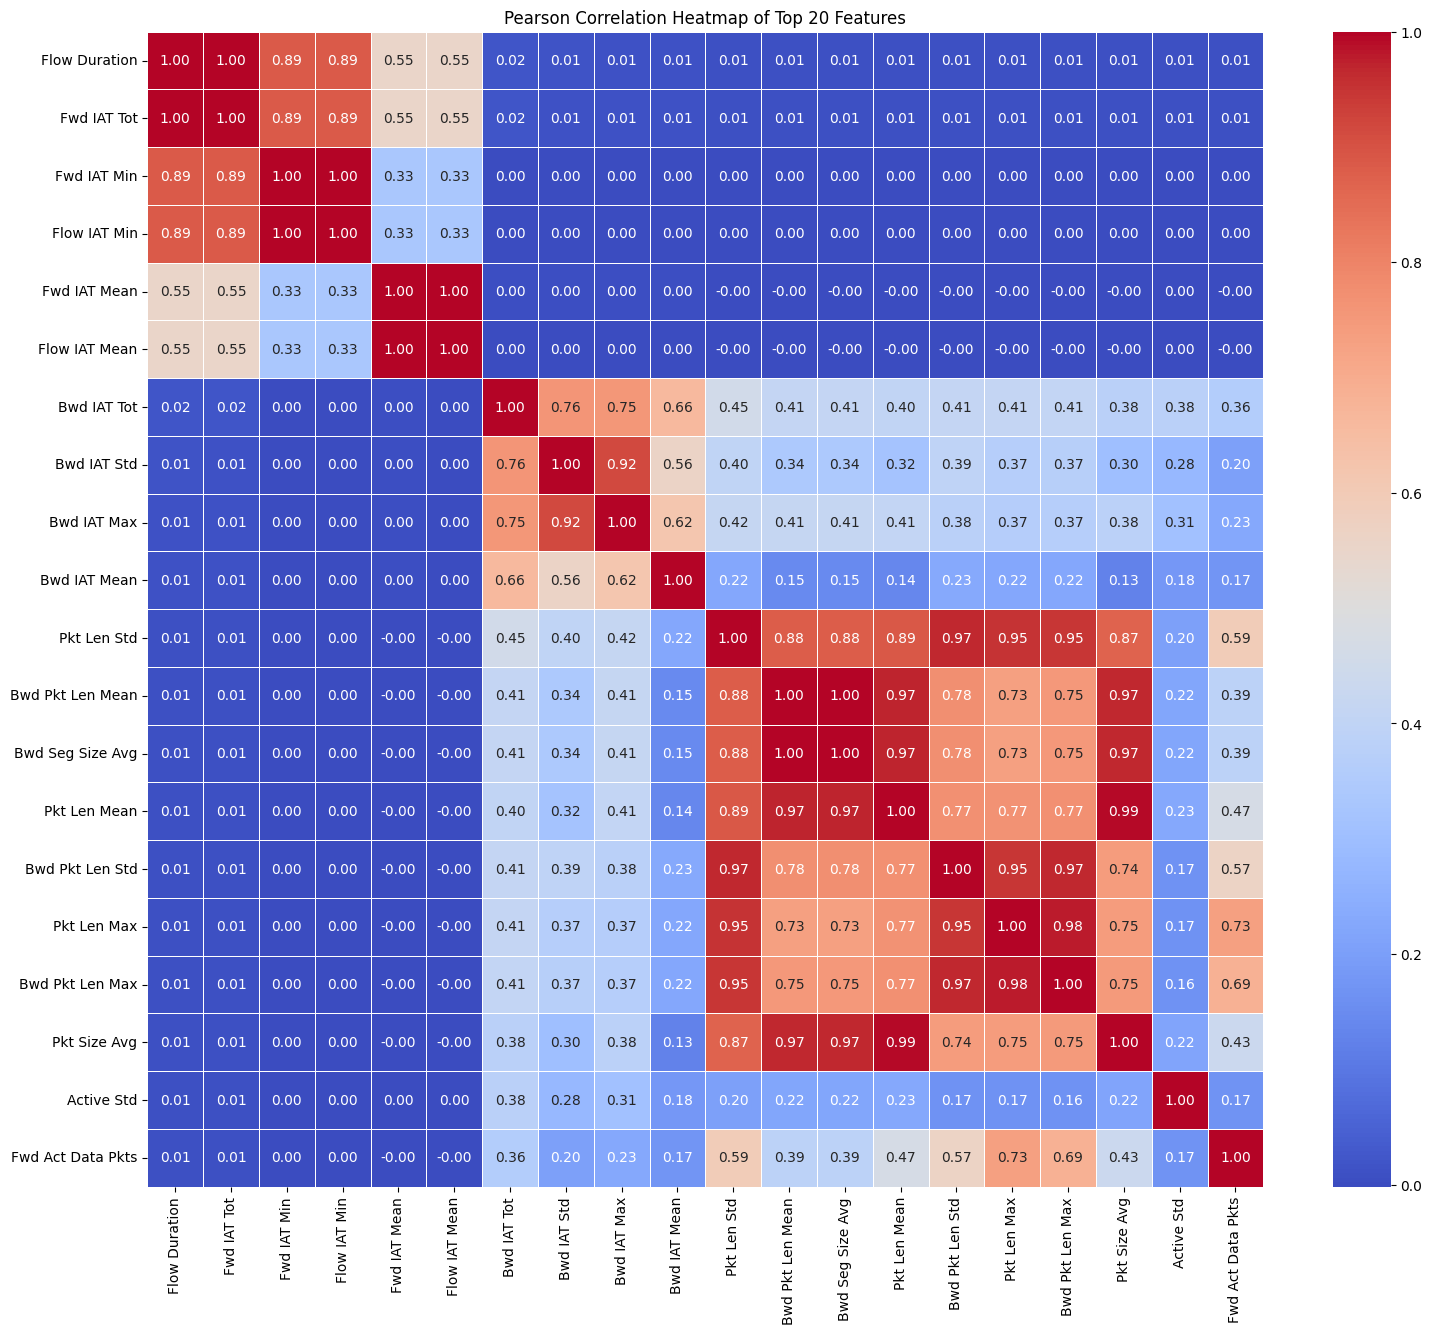

In [13]:
# Step 2: Plot a Pearson correlation heatmap of the top 20 features
correlation_matrix = df_dataset.corr(method='pearson')

# Select the top 20 most correlated features for better visualization
n_features = 20
top_correlated_features = correlation_matrix.nlargest(n_features, 'Flow Duration').index
top_correlation_matrix = df_dataset[top_correlated_features].corr()

plt.figure(figsize=(18, 15))
sns.heatmap(top_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title(f'Pearson Correlation Heatmap of Top {n_features} Features')
plt.show()

### Drops highly correlated features (threshold: 0.90) to reduce redundancy

In [14]:
# Step 3: Drops highly correlated features (threshold: 0.90) to reduce redundancy
X = df_dataset.drop('Label', axis=1, errors='ignore')
corr = X.corr().abs()

correlated_col = set()
is_correlated = [True] * len(corr.columns)
threshold = 0.90
for i in range (len(corr.columns)):
    if(is_correlated[i]):
        for j in range(i):
          if (corr.iloc[i, j] >= threshold) and (is_correlated[j]):
            colname = corr.columns[j]
            is_correlated[j]=False
            correlated_col.add(colname)

print("Highly correlated columns to drop:")
print(correlated_col)
print(f"Number of highly correlated columns to drop: {len(correlated_col)}")
df_dataset.drop(correlated_col, axis=1, inplace=True)
print(f"Shape after dropping highly correlated columns: {df_dataset.shape}")

Highly correlated columns to drop:
{'Idle Std', 'Flow IAT Mean', 'Pkt Len Mean', 'Tot Bwd Pkts', 'Active Mean', 'Idle Mean', 'Bwd Pkt Len Max', 'Bwd IAT Std', 'Flow IAT Min', 'Flow IAT Max', 'Fwd IAT Min', 'Flow Duration', 'RST Flag Cnt', 'Bwd Pkt Len Mean', 'Tot Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd IAT Std', 'Fwd IAT Max', 'Pkt Len Max', 'Fwd Pkt Len Min', 'Bwd Pkt Len Std', 'Flow IAT Std', 'Pkt Size Avg', 'Fwd Pkt Len Max'}
Number of highly correlated columns to drop: 24
Shape after dropping highly correlated columns: (1048575, 37)


### Remove Duplicate Rows

In [15]:
# Step 4: Remove Duplicate Rows
print(f"\nShape before dropping duplicate rows: {df_dataset.shape}")
initial_rows = df_dataset.shape[0]
df_dataset.drop_duplicates(inplace=True)
rows_dropped = initial_rows - df_dataset.shape[0]
print(f"Removed {rows_dropped} duplicate rows.")
print(f"Shape after dropping duplicate rows: {df_dataset.shape}")


Shape before dropping duplicate rows: (1048575, 37)
Removed 378742 duplicate rows.
Shape after dropping duplicate rows: (669833, 37)


### Label Counting

In [16]:
X = df_dataset.drop('Label', axis=1)
y = df_dataset['Label']
print("Distribution of target variable 'y':")
print(y.value_counts())

Distribution of target variable 'y':
Label
0    575789
1     94044
Name: count, dtype: int64


# Model Training -- Three Approaches

### Train-Test Split

In [17]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (468883, 36)
X_test shape: (200950, 36)
y_train shape: (468883,)
y_test shape: (200950,)


### Handling Imbalanced Class

In [18]:
from sklearn.utils import class_weight

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert to a dictionary for use in models
class_weights_dict = dict(enumerate(class_weights))

print("Calculated Class Weights:")
print(class_weights_dict)

Calculated Class Weights:
{0: np.float64(0.5816656411579647), 1: np.float64(3.5612629308380552)}


### Baseline XGBoost

In [19]:
# Initialize XGBoost Classifier with class weights for imbalance handling
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=RANDOM_STATE_SEED,
    scale_pos_weight=class_weights_dict[1] / class_weights_dict[0] # Adjust for binary classification
)


In [20]:
# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {accuracy_xgb*100} %")
print("XGBoost Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Accuracy: 100.0 %
XGBoost Confusion Matrix:
[[172737      0]
 [     0  28213]]


### GridSearchCV

In [ ]:
xgb_model_tuned = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=RANDOM_STATE_SEED,
    scale_pos_weight=class_weights_dict[1] / class_weights_dict[0]
)

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid for GridSearchCV
# The grid can be adjusted based on computational resources and desired search depth
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# Initialize GridSearchCV
# cv=3 for cross-validation, verbose to show progress, n_jobs=-1 to use all available cores
# scoring='accuracy' can be changed to 'f1', 'roc_auc' depending on the evaluation metric priority
grid_search = GridSearchCV(estimator=xgb_model_tuned, param_grid=param_grid,
                           cv=3, verbose=2, n_jobs=-1, scoring='accuracy')

print('Starting GridSearchCV for XGBoost hyperparameter tuning...')
# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)
print('GridSearchCV complete.')

print("Best parameters found: ", grid_search.best_params_)
print("Best score found: ", grid_search.best_score_)

# Get the best model from the search
best_xgb_model_grid = grid_search.best_estimator_

# Make predictions on the test set using the best model
y_pred_xgb_grid = best_xgb_model_grid.predict(X_test)

# Evaluate the best model
accuracy_xgb_grid = accuracy_score(y_test, y_pred_xgb_grid)
print(f"Best XGBoost (GridSearchCV) Accuracy: {accuracy_xgb_grid}")
print("Best XGBoost (GridSearchCV) Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_grid))

Starting GridSearchCV for XGBoost hyperparameter tuning...
Fitting 3 folds for each of 243 candidates, totalling 729 fits


### RandomizeSearchCV

In [21]:
from sklearn.model_selection import RandomizedSearchCV

# Define a reduced hyperparameter grid for RandomizedSearchCV to speed up tuning
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# Initialize RandomizedSearchCV
# n_iter is set to a lower value for quicker demonstration
random_search = RandomizedSearchCV(estimator=xgb_model, param_distributions=param_dist,
                                   n_iter=10, cv=3, verbose=2, random_state=RANDOM_STATE_SEED, n_jobs=-1, scoring='accuracy')

# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

print("Best parameters found: ", random_search.best_params_)
print("Best score found: ", random_search.best_score_)

# Get the best model from the search
best_xgb_model = random_search.best_estimator_

# Make predictions on the test set
y_pred_xgb = best_xgb_model.predict(X_test)

# Evaluate the model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {accuracy_xgb}")
print("XGBoost Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters found:  {'subsample': 0.9, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Best score found:  0.9999978672672443
XGBoost Accuracy: 0.9999950236377209
XGBoost Confusion Matrix:
[[172736      1]
 [     0  28213]]
